# 3D component creation and reuse

This example demonstrates how to create and use an HFSS 3D component by
performing the following:
1. Create a patch antenna using the HFSS 3D Modeler.
2. Save the antenna as a 3D component on the disk.
3. Import multiple instances of patch antenna as
   a 3D component in a new project to create a small array.
5. Set up the new design for simulation and optimization.

Keywords: **AEDT**, **Antenna**, **3D component**.

## Prerequisites

### Perform imports

In [1]:
# +
import os
import tempfile
import time

In [2]:
from ansys.aedt.core import Hfss
# -

### Define constants
Constants help ensure consistency and avoid repetition throughout the example.

In [3]:
AEDT_VERSION = "2024.2"
NG_MODE = False  # Open AEDT UI when it is launched.

### Create temporary directory

Create a temporary working directory.
The name of the working folder is stored in ``temp_folder.name``.

> **Note:** The final cell in the notebook cleans up the temporary folder. If you want to
> retrieve the AEDT project and data, do so before executing the final cell in the notebook.

This example creates two projects defined in `project_names. 
The first will be used to
create the patch antenna model and the 2nd project
will be used to demonstrate the use 3D components.

In [4]:
temp_folder = tempfile.TemporaryDirectory(suffix=".ansys")
project_names = [os.path.join(temp_folder.name, "start_project.aedt"),
                 os.path.join(temp_folder.name, "final_project.aedt"),
                ]

### Launch HFSS
AEDT is started when an instance of the ``Hfss()`` class is
instantiated. An HFSS design is automatically inserted in the
AEDT project.

In [5]:
hfss = Hfss(
    version=AEDT_VERSION,
    design="build_comp",
    new_desktop=True,  # Set to False if you want to connect to an existing AEDT session.
    close_on_exit=True,
    non_graphical=NG_MODE,
    solution_type="Modal",
)
hfss.save_project(project_names[0])

PyAEDT INFO: Python version 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)].


PyAEDT INFO: PyAEDT version 0.15.dev0.


PyAEDT INFO: Initializing new Desktop session.


PyAEDT INFO: Log on console is enabled.


PyAEDT INFO: Log on file C:\Users\ansys\AppData\Local\Temp\pyaedt_ansys_f03b210d-8217-4604-a4c1-d76ec00c0c97.log is enabled.


...

PyAEDT INFO: Project Project67 has been created.


PyAEDT INFO: Added design 'build_comp' of type HFSS.


PyAEDT INFO: Aedt Objects correctly read


PyAEDT INFO: Project start_project Saved correctly


True

## Model preparation

### Define parameters

Parameters can be defined in the HFSS design and subsequently 
used to optimiuze
performance, run parametric studies or 
explore the impact of tolerance on performance.

In [6]:
hfss["thickness"] = "0.1mm"
hfss["width"] = "1mm"

###  Build the antenna model

The compact, 
[pythonic syntax](https://docs.python-guide.org/writing/style/#code-style) 
allows you to create the model from simple
primitives. This patch antenna is comprised of the FR-4 substrate, a rectangle, 
and the coaxial
probe feed. Each primitive is of type ``Object3D``.

> **Note: ** The feed length of the patch antenna is fixed and is not
> parametric in HFSS.

In [7]:
# +
substrate = hfss.modeler.create_box(
    ["-width", "-width", "-thickness"],
    ["2*width", "2*width", "thickness"],
    material="FR4_epoxy",
    name="substrate",
)

PyAEDT INFO: Modeler class has been initialized! Elapsed time: 0m 1sec


PyAEDT INFO: Materials class has been initialized! Elapsed time: 0m 0sec


In [8]:
feed_length = "0.1mm"  # This parameter is defined only in Python and is not varied

In [9]:
patch = hfss.modeler.create_rectangle(
    "XY", ["-width/2", "-width/2", "0mm"], ["width", "width"], name="patch"
)

In [10]:
inner_conductor = hfss.modeler.create_cylinder(
    2,
    ["-width/8", "-width/4", f"-thickness - {feed_length}"],
    "0.01mm",
    f"thickness + {feed_length}",
    material="copper",
    name="via_inner",
)

In [11]:
via_outer = hfss.modeler.create_cylinder(
    2,
    ["-width/8", "-width/4", "-thickness"],
    "0.025mm",
    f"-{feed_length}",
    material="Teflon_based",
    name="via_teflon",
)
# -

### Assign boundaries

Boundary conditions can be assigned to faces or bodies in the model
using methods of the ``Hfss`` class.

In [12]:
hfss.assign_perfecte_to_sheets(patch, name="patch_bc")

PyAEDT INFO: Boundary Perfect E patch_bc has been created.


### Assign boundaries to the via

The following statement selects the outer surface of the cylinder 
``via_outer``, excluding the upper and lower faces, and assigns
the "perfect conductor" boundary condition.

In [13]:
# +
side_face = [i for i in via_outer.faces if i.id not in 
             [via_outer.top_face_z.id, via_outer.bottom_face_z.id]
            ]

In [14]:
hfss.assign_perfecte_to_sheets(side_face, name="feed_gnd")
hfss.assign_perfecte_to_sheets(substrate.bottom_face_z, name="ground_plane")
hfss.assign_perfecth_to_sheets(via_outer.top_face_z, name="feed_thru")  # Ensure power flows through the ground plane.
hfss.change_material_override(material_override=True)  # Allow the probe feed to extend outside the substrate.
# -

PyAEDT INFO: Boundary Perfect E feed_gnd has been created.


PyAEDT INFO: Boundary Perfect E ground_plane has been created.


PyAEDT INFO: Boundary Perfect H feed_thru has been created.


PyAEDT INFO: Enabling Material Override


True

### Create wave port

A wave port is assigned to the bottom face of the via. Note that the property `via_outer.bottom_face_z` 
is a ``FacePrimitive`` object.

In [15]:
p1 = hfss.wave_port(
    via_outer.bottom_face_z,
    name="P1",
    create_pec_cap=True
)

PyAEDT INFO: Boundary Wave Port P1 has been created.


### Query the object properties

Everything in Python is an object. You can use the object
properties to obtain detailed information as shown below:

In [16]:
out_str = f"A port named '{p1.name}' was assigned to a surface object"
out_str += f" of type \n   {type(via_outer.bottom_face_z)}\n"
out_str += f"which is located at the bottom surface of the object '{via_outer.name}'\n"
out_str += f"at the z-elevation: {via_outer.bottom_face_z.bottom_edge_z} "
out_str += f"{hfss.modeler.model_units}\n"
out_str += f"and has the face ID: {via_outer.bottom_face_z.id}."
print(out_str)

A port named 'P1' was assigned to a surface object of type 
   <class 'ansys.aedt.core.modeler.cad.elements_3d.FacePrimitive'>
which is located at the bottom surface of the object 'via_teflon'
at the z-elevation: 59 mm
and has the face ID: 57.


## Create 3D component

You can now create a 3D component from the antenna model. The following statements
save the component to the specified location with the name "patch_antenna".

In [17]:
component_path = os.path.join(temp_folder.name, "patch_antenna.a3dcomp")
hfss.modeler.create_3dcomponent(component_path, name="patch_antenna")

PyAEDT INFO: Mesh class has been initialized! Elapsed time: 0m 0sec


PyAEDT INFO: Mesh class has been initialized! Elapsed time: 0m 0sec


True

A 2nd instance of HFSS is created to demonstrate how the new 3D component can be
used within a new design.

In [18]:
hfss2 = Hfss(
    version=AEDT_VERSION,
    project=project_names[1],
    design="new_design",
    solution_type="Modal",
)
hfss2.change_material_override(material_override=True)

PyAEDT INFO: Python version 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)].


PyAEDT INFO: PyAEDT version 0.15.dev0.


PyAEDT INFO: Returning found Desktop session with PID 9684!


PyAEDT INFO: Project final_project has been created.


PyAEDT INFO: Added design 'new_design' of type HFSS.


PyAEDT INFO: Aedt Objects correctly read


PyAEDT INFO: Enabling Material Override


True

### Insert 3D components

Place 4 antennas to make a small array. 
- The substrate thickness is modified by creating the parameter "p_thick" and
  assigning it to the "thickness" parameter of the components.
- The first antenna is placed at the origin.
- The spacing between elements is defined by the parameter $2\times w$

In [19]:
# +
# Define a parameter to use for the substrate thickness.
hfss2["p_thick"] = "0.2mm"

In [20]:
# Define a parameter to specify the patch width.
hfss2["w"] = "1mm"

In [21]:
# [x, y, z] location of the patch elements.
positions = [["2*w", "w", 0], ["-2*w", "w", 0], [0, "2.5*w", 0]]

In [22]:
# Keep track of patch elements and their coordinate systems in Python lists:
elements = []
cs = []

In [23]:
# The first patch is located at the origin.
elements.append(hfss2.modeler.insert_3d_component(component_path, name="patch_0"))
elements[0].parameters["thickness"] = "p_thick"
elements[0].parameters["width"] = "w"

PyAEDT INFO: Modeler class has been initialized! Elapsed time: 0m 0sec


PyAEDT INFO: Parsing C:/Users/ansys/AppData/Local/Temp/tmpl8vyyuwl.ansys/final_project.aedt.


PyAEDT INFO: File C:/Users/ansys/AppData/Local/Temp/tmpl8vyyuwl.ansys/final_project.aedt correctly loaded. Elapsed time: 0m 0sec


PyAEDT INFO: aedt file load time 0.0


In [24]:
# Now place the other 3 patches:
count = 1
for p in positions:
    cs.append(hfss2.modeler.create_coordinate_system(origin=p, name="cs_" + str(count)))  # Create the patch coordinate system.
    elements.append(hfss2.modeler.insert_3d_component(component_path,  # Place the patch element.
                                                      coordinate_system=cs[-1].name,
                                                      name="patch_" + str(count))
                    )
    count +=1

    elements[-1].parameters["thickness"] = "p_thick"
    elements[-1].parameters["width"] = "w"
# -

You can inspect the component parameters.

In [25]:
units = hfss2.modeler.model_units  # Retrieve the length units as a string.
for e in elements:
    print(f"Component '{e.name}' is located at (x={e.center[0]} {units}, y={e.center[1]} {units})")

Component 'patch_0' is located at (x=0.0 mm, y=0.0 mm)


Component 'patch_1' is located at (x=2.0 mm, y=1.0 mm)


Component 'patch_2' is located at (x=-2.0 mm, y=1.0 mm)


Component 'patch_3' is located at (x=0.0 mm, y=2.5 mm)


### Move 3D components

The position of each 3D component can be changed by modifying the ``origin`` 
of the corresponding coordinate system.

In [26]:
hfss2.modeler.coordinate_systems[0].origin = [0, "2*w", 0]

### Create air region

The volume of the solution domain is defined
by an air region object. The following cell creates the
region object and assigns the radiation boundary to the outer surfaces of 
the region.

In [27]:
hfss2.modeler.create_air_region( x_pos=2, y_pos=2, z_pos=2.5, x_neg=2, y_neg=2, z_neg=2, is_percentage=False)
hfss2.assign_radiation_boundary_to_faces(hfss2.modeler["Region"].faces)

PyAEDT INFO: Boundary Radiation Rad__UV5YN9 has been created.


### Create solution setup and optimetrics analysis

Once a project is ready to be solved, define the solution setup and parametric analysis.

In [28]:
# +
setup1 = hfss2.create_setup(RangeStart="60GHz", RangeEnd="80GHz")
optim = hfss2.parametrics.add("w", start_point="0.8mm",
                              end_point="1.2mm",
                              step="0.05mm",
                              variation_type="LinearStep",
                              name="Sweep Patch Width")

PyAEDT INFO: Key RangeStart matched internal key 'MaxDeltaS' with confidence of 42.


PyAEDT INFO: Key RangeEnd matched internal key 'Target' with confidence of 42.


In [29]:
if hfss.valid_design:
    print(f"The HFSS design '{hfss.design_name}' is ready to solve.")
else:
    print(f"Something is not quite right.")
# -

The HFSS design 'build_comp' is ready to solve.


### Visualize the model

PyAEDT INFO: PostProcessor class has been initialized! Elapsed time: 0m 0sec


PyAEDT INFO: Post class has been initialized! Elapsed time: 0m 0sec


C:\actions-runner\_work\pyaedt-examples\pyaedt-examples\.venv\lib\site-packages\pyvista\jupyter\notebook.py:37: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


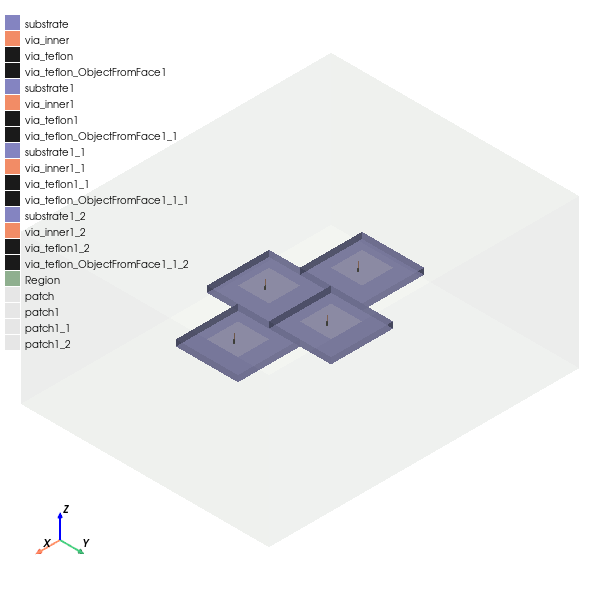

In [30]:
hfss2.modeler.fit_all()
hfss2.plot(
    show=False,
    output_file=os.path.join(hfss.working_directory, "Image.jpg"),
    plot_air_objects=True,
)

## Finish

### Save the project

In [31]:
hfss2.save_project()
hfss2.release_desktop()
# Wait 3 seconds to allow AEDT to shut down before cleaning the temporary directory.
time.sleep(3)

PyAEDT INFO: Project final_project Saved correctly


PyAEDT INFO: Desktop has been released and closed.


### Clean up

All project files are saved in the folder ``temp_folder.name``.
If you've run this example as a Jupyter notebook, you
can retrieve those project files. The following cell
removes all temporary files, including the project folder.

In [32]:
temp_folder.cleanup()